In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as pgo
from plotly import express as px
import ipynbname
import uproot
from pathlib import Path
import polars as pl
from tqdm.auto import tqdm

In [2]:
base_dir = ipynbname.path().parents[3]
sim_data_dir = Path("/data/fanghan/opengate_sim/data/batch_2")
dc_spect_mc_root_filename = "run_0_detector_hits.root"
# Show branches of the DetectorActor tree
with uproot.open(sim_data_dir / dc_spect_mc_root_filename) as file:
    file["DetectorHitsActor"].show()
# Put branch names in a list
branch_names = file["DetectorHitsActor"].keys()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
RunID                | int32_t                  | AsDtype('>i4')
ThreadID             | int32_t                  | AsDtype('>i4')
EventID              | int32_t                  | AsDtype('>i4')
TrackID              | int32_t                  | AsDtype('>i4')
PreKineticEnergy     | double                   | AsDtype('>f8')
PrePosition_X        | double                   | AsDtype('>f8')
PrePosition_Y        | double                   | AsDtype('>f8')
PrePosition_Z        | double                   | AsDtype('>f8')
PrePositionLocal_X   | double                   | AsDtype('>f8')
PrePositionLocal_Y   | double                   | AsDtype('>f8')
PrePositionLocal_Z   | double                   | AsDtype('>f8')
PostKineticEnergy    | double                   | AsDtype('>f8')
PostPosition_X       | double                   | AsDtype(

In [4]:
# Scan through all runs in the folder
# We need to parse the run number from the filename, so we can sort them correctly
# First get a list of all root files in the directory
root_files = list(sim_data_dir.glob("run_*_detector_hits.root"))
# Extract run numbers and sort files by run number
def extract_run_number(filename):
    # Assuming filename format is "run_{run_number}_detector_hits.root"
    parts = filename.stem.split("_")
    for i, part in enumerate(parts):
        if part == "run" and i + 1 < len(parts):
            return int(parts[i + 1])
    return -1  # Return -1 if run number not found
# Sort files by extracted run number
root_files.sort(key=extract_run_number)
print("Sorted root files by run number:")
for f in root_files:
    print(f.name)

for root_file in root_files:
    with uproot.open(root_file) as file:
        # Print unique RunId values in the file
        run_ids = file["DetectorHitsActor"]["RunID"].array(library="np")
        unique_run_ids = np.unique(run_ids)
        print(f"File: {root_file.name}, Unique RunIds: {unique_run_ids}")


Sorted root files by run number:
run_0_detector_hits.root
run_1_detector_hits.root
run_2_detector_hits.root
run_3_detector_hits.root
run_4_detector_hits.root
run_5_detector_hits.root
run_6_detector_hits.root
run_7_detector_hits.root
run_8_detector_hits.root
run_9_detector_hits.root
File: run_0_detector_hits.root, Unique RunIds: [0]
File: run_1_detector_hits.root, Unique RunIds: [0]
File: run_2_detector_hits.root, Unique RunIds: [0]
File: run_3_detector_hits.root, Unique RunIds: [0]
File: run_4_detector_hits.root, Unique RunIds: [0]
File: run_5_detector_hits.root, Unique RunIds: [0]
File: run_6_detector_hits.root, Unique RunIds: [0]
File: run_7_detector_hits.root, Unique RunIds: [0]
File: run_8_detector_hits.root, Unique RunIds: [0]
File: run_9_detector_hits.root, Unique RunIds: [0]


In [5]:
# Load all runs into one Polars DataFrame
for i, branch_name in enumerate(branch_names):
    print(f"{i}: {branch_name}")
print("-" * 40)

# Keep all physics-relevant branches and ensure key IDs are present
required = {"EventID", "TrackID", "PreKineticEnergy", "PostKineticEnergy"}
selected_branches = list(branch_names)
missing = required.difference(set(selected_branches))
if missing:
    raise ValueError(f"Missing required branches: {sorted(missing)}")

for i, branch_name in enumerate(selected_branches):
    print(f"{i}: {branch_name}")

0: RunID
1: ThreadID
2: EventID
3: TrackID
4: PreKineticEnergy
5: PrePosition_X
6: PrePosition_Y
7: PrePosition_Z
8: PrePositionLocal_X
9: PrePositionLocal_Y
10: PrePositionLocal_Z
11: PostKineticEnergy
12: PostPosition_X
13: PostPosition_Y
14: PostPosition_Z
15: PostPositionLocal_X
16: PostPositionLocal_Y
17: PostPositionLocal_Z
18: TotalEnergyDeposit
19: StepLength
20: GlobalTime
21: LocalTime
22: TimeFromBeginOfEvent
23: EventPosition_X
24: EventPosition_Y
25: EventPosition_Z
26: EventKineticEnergy
27: ParticleType
28: TrackCreatorProcess
29: ProcessDefinedStep
----------------------------------------
0: RunID
1: ThreadID
2: EventID
3: TrackID
4: PreKineticEnergy
5: PrePosition_X
6: PrePosition_Y
7: PrePosition_Z
8: PrePositionLocal_X
9: PrePositionLocal_Y
10: PrePositionLocal_Z
11: PostKineticEnergy
12: PostPosition_X
13: PostPosition_Y
14: PostPosition_Z
15: PostPositionLocal_X
16: PostPositionLocal_Y
17: PostPositionLocal_Z
18: TotalEnergyDeposit
19: StepLength
20: GlobalTime
21:

In [6]:
# Load selected branches and create stable IDs across files
dfs = []
for root_file in tqdm(root_files, desc="Loading root files"):
    with uproot.open(root_file) as file:
        file_run_id = extract_run_number(root_file)
        data = file["DetectorHitsActor"].arrays(selected_branches, library="np")
        df = pl.DataFrame(data).with_columns(
            pl.lit(file_run_id).alias("FileRunID")
        )
        dfs.append(df)

hits_pl = pl.concat(dfs).with_columns(
    pl.struct(["FileRunID", "EventID"]).alias("EventKey")
    )

Loading root files:   0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
# Count hits per unique event key (FileRunID, EventID)
event_counts = (
    hits_pl
    .group_by("EventKey")
    .agg(pl.len().alias("HitCountPerEvent"))
    .sort("HitCountPerEvent", descending=True)
    )

print(event_counts.head(10))
print(event_counts["HitCountPerEvent"].describe())

shape: (10, 2)
┌──────────────┬──────────────────┐
│ EventKey     ┆ HitCountPerEvent │
│ ---          ┆ ---              │
│ struct[2]    ┆ u32              │
╞══════════════╪══════════════════╡
│ {3,7187093}  ┆ 11               │
│ {6,26820263} ┆ 10               │
│ {0,10219934} ┆ 9                │
│ {8,16999334} ┆ 9                │
│ {9,36431498} ┆ 8                │
│ {4,36180320} ┆ 8                │
│ {3,37034050} ┆ 8                │
│ {6,61838364} ┆ 8                │
│ {5,36417735} ┆ 7                │
│ {5,47084231} ┆ 7                │
└──────────────┴──────────────────┘
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 398754.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 1.120698 │
│ std        ┆ 0.359085 │
│ min        ┆ 1.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 1.0      │
│ max        ┆ 11.0     │
└────────────┴──────────┘


In [23]:
400_000/640_000_000*100

0.0625

In [8]:
# Calculate energy deposition per hit and persist it in hits_pl
hits_pl = hits_pl.with_columns(
    ((pl.col("PreKineticEnergy") - pl.col("PostKineticEnergy")) * 1e3).alias(
        "EnergyDepositionKeV"
    )
)
energy_deposition_per_hit_keV = hits_pl["EnergyDepositionKeV"]

total_energy_deposition_keV = hits_pl["TotalEnergyDeposit"] * 1e3

# Compare kinetic-energy loss and TotalEnergyDeposit for each hit
diff_hit_keV = np.abs(
    (hits_pl["PreKineticEnergy"] - hits_pl["PostKineticEnergy"]) * 1e3
    - hits_pl["TotalEnergyDeposit"] * 1e3
)
max_diff_keV = float(diff_hit_keV.max())
mean_diff_keV = float(diff_hit_keV.mean())

reference_keV = 140.0
rel_max = max_diff_keV / reference_keV
tol_keV = 1e-10
status = "PASS" if max_diff_keV < tol_keV else "CHECK"

print("=" * 80)
print(f"ENERGY CONSISTENCY CHECK: {status}")
print(f"Max |(Pre-Post) - TotalEnergyDeposit| = {max_diff_keV:.16e} keV")
print(f"Mean |(Pre-Post) - TotalEnergyDeposit| = {mean_diff_keV:.16e} keV")
print(f"Relative max error vs 140 keV = {rel_max:.3e}")
print("Interpretation: difference is numerical round-off; values are effectively identical.")
print("=" * 80)

ENERGY CONSISTENCY CHECK: PASS
Max |(Pre-Post) - TotalEnergyDeposit| = 1.4210854715202004e-14 keV
Mean |(Pre-Post) - TotalEnergyDeposit| = 1.6213147297348308e-16 keV
Relative max error vs 140 keV = 1.015e-16
Interpretation: difference is numerical round-off; values are effectively identical.


In [9]:
# Gamma-specific mismatch diagnostics by interaction process
gamma_hits = hits_pl.filter(pl.col("ParticleType") == "gamma").with_columns(
    ((pl.col("PreKineticEnergy") - pl.col("PostKineticEnergy")) * 1e3).alias("GammaEnergyLossKeV"),
    (pl.col("TotalEnergyDeposit") * 1e3).alias("GammaTotalEdepKeV"),
)

gamma_diff_keV = np.abs(gamma_hits["GammaEnergyLossKeV"] - gamma_hits["GammaTotalEdepKeV"] )
print("Gamma-hit diagnostic:")
print(f"  Number of gamma hits: {len(gamma_hits):,}")
print(f"  Max |(Pre-Post) - TotalEnergyDeposit| for gamma hits: {gamma_diff_keV.max():.16e} keV")
print(f"  Mean |(Pre-Post) - TotalEnergyDeposit| for gamma hits: {gamma_diff_keV.mean():.16e} keV")

process_summary = (
    gamma_hits
    .group_by("ProcessDefinedStep")
    .agg(
        pl.len().alias("n_hits"),
        pl.col("GammaEnergyLossKeV").mean().alias("mean_loss_keV"),
        pl.col("GammaEnergyLossKeV").max().alias("max_loss_keV"),
        pl.col("GammaEnergyLossKeV").min().alias("min_loss_keV"),
        (pl.col("GammaEnergyLossKeV") - pl.col("GammaTotalEdepKeV")).abs().max().alias("max_abs_diff_keV"),
    )
    .sort("n_hits", descending=True)
)

print("\nGamma-hit summary by ProcessDefinedStep:")
print(process_summary.head(10))
print("\nProcesses with any nonzero mismatch above 1e-10 keV:")
print(process_summary.filter(pl.col("max_abs_diff_keV") > 1e-10))

Gamma-hit diagnostic:
  Number of gamma hits: 446,523
  Max |(Pre-Post) - TotalEnergyDeposit| for gamma hits: 1.4210854715202004e-14 keV
  Mean |(Pre-Post) - TotalEnergyDeposit| for gamma hits: 1.6170578628187436e-16 keV

Gamma-hit summary by ProcessDefinedStep:
shape: (2, 6)
┌────────────────────┬────────┬───────────────┬──────────────┬──────────────┬──────────────────┐
│ ProcessDefinedStep ┆ n_hits ┆ mean_loss_keV ┆ max_loss_keV ┆ min_loss_keV ┆ max_abs_diff_keV │
│ ---                ┆ ---    ┆ ---           ┆ ---          ┆ ---          ┆ ---              │
│ str                ┆ u32    ┆ f64           ┆ f64          ┆ f64          ┆ f64              │
╞════════════════════╪════════╪═══════════════╪══════════════╪══════════════╪══════════════════╡
│ phot               ┆ 392256 ┆ 135.292546    ┆ 140.0        ┆ 7.120781     ┆ 1.4211e-14       │
│ compt              ┆ 54267  ┆ 23.814699     ┆ 49.556027    ┆ 0.000305     ┆ 0.0              │
└────────────────────┴────────┴─────────────

Edge width: 1.0 keV


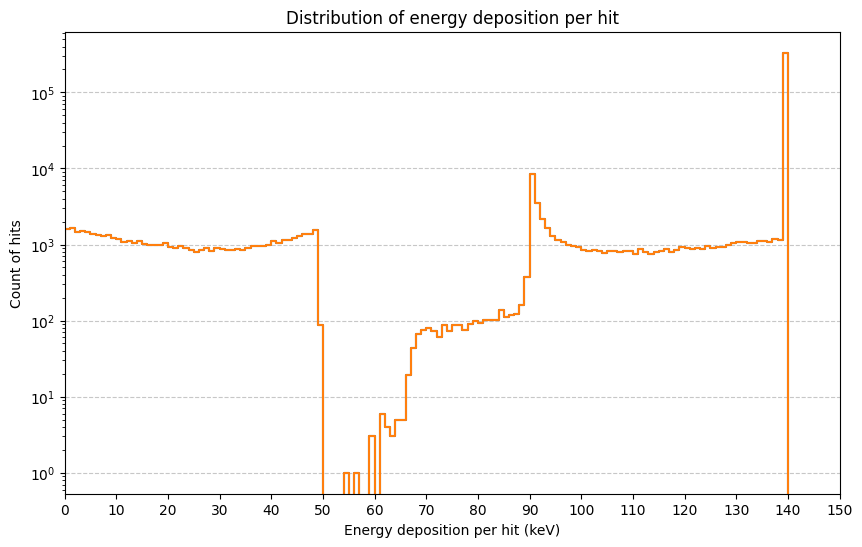

In [10]:


bins = np.linspace(0, 150, 151) - 0.5
hist, edges = np.histogram(energy_deposition_per_hit_keV, bins=bins)
hist_total, edges_total = np.histogram(total_energy_deposition_keV, bins=bins)
print(f"Edge width: {edges[1] - edges[0]} keV")
plt.figure(figsize=(10, 6))
# Bar plot using step lines
plt.step(edges[:-1] + 0.5, hist)
plt.step(edges_total[:-1] + 0.5, hist_total)
plt.yscale("log")
plt.xlabel("Energy deposition per hit (keV)")
plt.xlim(0, 150)
# Set x-ticks to be every 10 keV
plt.xticks(np.arange(0, 151, 10))
plt.ylabel("Count of hits")
plt.title("Distribution of energy deposition per hit")
# Add only horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

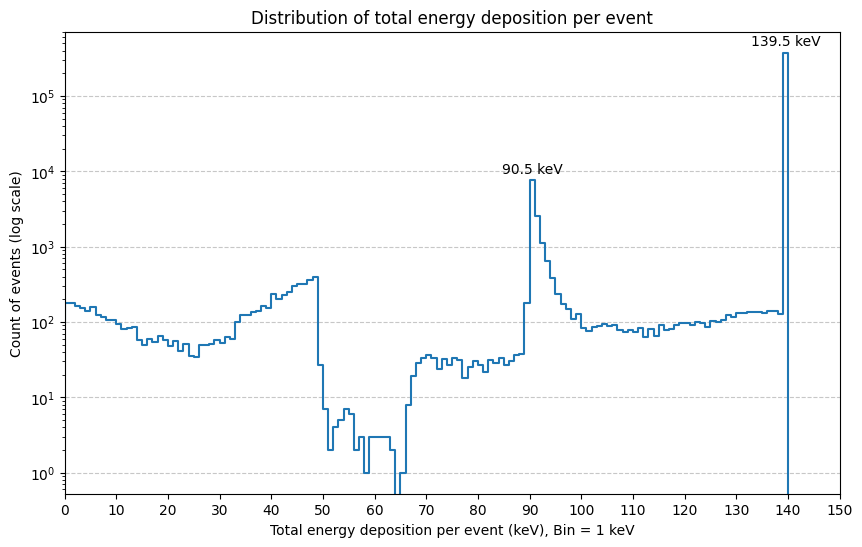

In [12]:
# Find the peaks in the histogram
from scipy.signal import find_peaks

# Sum EnergyDepositionKeV for hits sharing the same EventKey (FileRunID, EventID)
energy_deposition_keV_per_event = hits_pl.group_by("EventKey").agg(
    pl.col("EnergyDepositionKeV").sum().alias("TotalEnergyDeposition")
)
energy_deposition_per_event = energy_deposition_keV_per_event

# Plot histogram of energy deposition per event
energy_deposition_per_event_keV = energy_deposition_keV_per_event[
    "TotalEnergyDeposition"
].to_numpy()
plt.figure(figsize=(10, 6))
bin_edges = np.arange(0, 151, 1) - 0.5
hist, edges = np.histogram(energy_deposition_per_event_keV, bins=bin_edges)
plt.step(edges[:-1] + 0.5, hist)
plt.yscale("log")
plt.xlabel("Total energy deposition per event (keV), Bin = 1 keV")
plt.ylabel("Count of events (log scale)")


peaks, _ = find_peaks(hist, height=1e3)  # Adjust height as needed
for peak in peaks:
    plt.annotate(
        f"{edges[peak]:.1f} keV",
        (edges[peak], hist[peak]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
    )

plt.xlim(0, 150)
# Set x-ticks to be every 10 keV
plt.xticks(np.arange(0, 151, 10))
#


plt.title("Distribution of total energy deposition per event")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [13]:
# Inspect particle types and creator processes to see whether secondary hits are recorded
particle_summary = (
    hits_pl
    .group_by(["ParticleType", "TrackCreatorProcess", "ProcessDefinedStep"])
    .agg(
        pl.len().alias("n_hits"),
        pl.col("EnergyDepositionKeV").sum().alias("sum_edep_keV"),
    )
    .sort("n_hits", descending=True)
)

print("Particle/creator-process summary (top 20):")
print(particle_summary.head(20))

print("\nUnique ParticleType values:")
print(hits_pl["ParticleType"].unique())

print("\nUnique TrackCreatorProcess values:")
print(hits_pl["TrackCreatorProcess"].unique())

secondary_like = hits_pl.filter(~pl.col("TrackCreatorProcess").is_in(["primary", "initStep", "InitStep"]))
print(f"\nHits with non-primary creator process: {len(secondary_like):,}")
if len(secondary_like) > 0:
    print(secondary_like.group_by(["ParticleType", "TrackCreatorProcess"]).agg(pl.len().alias("n_hits")).sort("n_hits", descending=True).head(20))

Particle/creator-process summary (top 20):
shape: (8, 5)
┌──────────────┬─────────────────────┬───────────────────────┬────────┬──────────────┐
│ ParticleType ┆ TrackCreatorProcess ┆ ProcessDefinedStep    ┆ n_hits ┆ sum_edep_keV │
│ ---          ┆ ---                 ┆ ---                   ┆ ---    ┆ ---          │
│ str          ┆ str                 ┆ str                   ┆ u32    ┆ f64          │
╞══════════════╪═════════════════════╪═══════════════════════╪════════╪══════════════╡
│ gamma        ┆ none                ┆ phot                  ┆ 392255 ┆ 5.3069e7     │
│ gamma        ┆ none                ┆ compt                 ┆ 54267  ┆ 1.2924e6     │
│ lepton       ┆ compt               ┆ TransportationWithMsc ┆ 299    ┆ 1114.08019   │
│ lepton       ┆ compt               ┆ eIoni                 ┆ 38     ┆ 356.454305   │
│ lepton       ┆ phot                ┆ TransportationWithMsc ┆ 19     ┆ 180.375787   │
│ lepton       ┆ phot                ┆ eIoni                 ┆ 2      ┆ 7

In [17]:
# Reconstruct 80 crystal centroids/bases from simulation geometry, then map PrePosition to crystal-local coordinates
import pandas as pd
from scipy.spatial.transform import Rotation

persistent_data_dir = Path(base_dir) / "persistent_data"
xlsx_path = (
    persistent_data_dir
    / "spreadsheet"
    / "MDSL.excel80M10RFR.cut-plate.010.150roi.2.30pin.105ellipse.xlsx"
)

if not xlsx_path.exists():
    raise FileNotFoundError(f"Geometry spreadsheet not found: {xlsx_path}")

# Parse geometry exactly like dc_spect_run_sim_batch.py
df_coords = pd.read_excel(xlsx_path, sheet_name="Coordinates")
df_coords.columns = df_coords.iloc[0]
df_coords = df_coords[1:].reset_index(drop=True)
df_coords = df_coords.apply(pd.to_numeric, errors="coerce")

collimator_body_length_mm = df_coords["length of collimator"].to_numpy(dtype=float)
hole_xyz_mm = df_coords[[
    "x coordinate value at center of hole",
    "y coordinate value at center of hole",
    "z coordinate value at center of hole",
]].to_numpy(dtype=float)

if np.isnan(collimator_body_length_mm).any() or np.isnan(hole_xyz_mm).any():
    raise ValueError("NaN found in geometry spreadsheet required fields")

detector_size_mm = np.array([50.0, 50.0, 10.0], dtype=float)
half_size_mm = detector_size_mm * 0.5

hole_r_mm = np.linalg.norm(hole_xyz_mm, axis=1)
azimuth_deg = np.degrees(np.arctan2(hole_xyz_mm[:, 1], hole_xyz_mm[:, 0]))
hole_r_xy_mm = np.linalg.norm(hole_xyz_mm[:, :2], axis=1)
polar_deg = np.degrees(np.arctan2(hole_xyz_mm[:, 2], hole_r_xy_mm))

# Global centroids of each crystal (80,3)
crystal_center_r_mm = hole_r_mm + collimator_body_length_mm + half_size_mm[2]
crystal_centers_mm = crystal_center_r_mm.reshape(-1, 1) * np.column_stack(
    [
        np.cos(np.radians(polar_deg)) * np.cos(np.radians(azimuth_deg)),
        np.cos(np.radians(polar_deg)) * np.sin(np.radians(azimuth_deg)),
        np.sin(np.radians(polar_deg)),
    ]
)

# Same rotation chain as simulation script
rx_0 = Rotation.from_euler("x", -90, degrees=True).as_matrix()
rz_0 = Rotation.from_euler("z", 90, degrees=True).as_matrix()
crystal_rot_mats = []
for i in range(len(crystal_centers_mm)):
    rz_1 = Rotation.from_euler("z", azimuth_deg[i], degrees=True).as_matrix()
    rx_1 = Rotation.from_euler("x", -polar_deg[i], degrees=True).as_matrix()
    crystal_rot_mats.append(rz_1 @ rz_0 @ rx_1 @ rx_0)
crystal_rot_mats = np.stack(crystal_rot_mats, axis=0)  # (80, 3, 3), local->global

crystal_basis_df = pl.DataFrame(
    {
        "CrystalID": np.arange(80, dtype=int),
        "Center_X_mm": crystal_centers_mm[:, 0],
        "Center_Y_mm": crystal_centers_mm[:, 1],
        "Center_Z_mm": crystal_centers_mm[:, 2],
        "Ux_X": crystal_rot_mats[:, 0, 0], "Ux_Y": crystal_rot_mats[:, 1, 0], "Ux_Z": crystal_rot_mats[:, 2, 0],
        "Uy_X": crystal_rot_mats[:, 0, 1], "Uy_Y": crystal_rot_mats[:, 1, 1], "Uy_Z": crystal_rot_mats[:, 2, 1],
        "Uz_X": crystal_rot_mats[:, 0, 2], "Uz_Y": crystal_rot_mats[:, 1, 2], "Uz_Z": crystal_rot_mats[:, 2, 2],
    }
)
print("Crystal centroids/bases (first 5 of 80):")
print(crystal_basis_df.head(5))

required_pre_cols = ["PrePosition_X", "PrePosition_Y", "PrePosition_Z"]
missing_pre_cols = [c for c in required_pre_cols if c not in hits_pl.columns]
if missing_pre_cols:
    raise ValueError(f"Missing required pre-position columns: {missing_pre_cols}")

def map_preposition_to_crystal_local(
    hits_df: pl.DataFrame,
    centers_mm: np.ndarray,
    rot_mats: np.ndarray,
    half_size: np.ndarray,
    batch_size: int = 50_000,
    tol_mm: float = 1e-6,
):
    n_hits = hits_df.height
    crystal_id = np.full(n_hits, -1, dtype=np.int16)
    pre_local = np.full((n_hits, 3), np.nan, dtype=np.float64)

    for start in tqdm(range(0, n_hits, batch_size), desc="Assigning crystal IDs from PrePosition"):
        stop = min(start + batch_size, n_hits)
        pre_global = hits_df.slice(start, stop - start).select(required_pre_cols).to_numpy()

        # Candidate crystal = nearest centroid in global coordinates
        delta_all = pre_global[:, None, :] - centers_mm[None, :, :]
        dist2 = np.einsum("nij,nij->ni", delta_all, delta_all)
        cand = np.argmin(dist2, axis=1)

        # local = (global - center) * [ux uy uz] == row-vector form using R (local->global)
        d = pre_global - centers_mm[cand]
        local = np.einsum("ni,nij->nj", d, rot_mats[cand])
        inside = np.all(np.abs(local) <= (half_size + tol_mm), axis=1)

        crystal_id[start:stop] = np.where(inside, cand, -1)
        pre_local[start:stop, :] = local

    return crystal_id, pre_local

crystal_id_pre, pre_local_xyz = map_preposition_to_crystal_local(
    hits_pl, crystal_centers_mm, crystal_rot_mats, half_size_mm
)

hits_pl = hits_pl.with_columns(
    pl.Series("CrystalID_fromPre", crystal_id_pre),
    pl.Series("PreLocal_X_calc_mm", pre_local_xyz[:, 0]),
    pl.Series("PreLocal_Y_calc_mm", pre_local_xyz[:, 1]),
    pl.Series("PreLocal_Z_calc_mm", pre_local_xyz[:, 2]),
)

assigned_mask = hits_pl["CrystalID_fromPre"] >= 0
n_assigned = int(assigned_mask.sum())
print(f"Assigned hits to crystals from PrePosition bounds: {n_assigned:,}/{hits_pl.height:,} ({n_assigned / hits_pl.height:.3%})")

if "PrePositionLocal_X" in hits_pl.columns:
    local_err_xyz = np.column_stack(
        [
            hits_pl["PreLocal_X_calc_mm"].to_numpy() - hits_pl["PrePositionLocal_X"].to_numpy(),
            hits_pl["PreLocal_Y_calc_mm"].to_numpy() - hits_pl["PrePositionLocal_Y"].to_numpy(),
            hits_pl["PreLocal_Z_calc_mm"].to_numpy() - hits_pl["PrePositionLocal_Z"].to_numpy(),
        ]
    )
    print("Validation vs PrePositionLocal branches:")
    print(f"  MAE [x,y,z] mm = {np.nanmean(np.abs(local_err_xyz), axis=0)}")
    print(f"  RMSE [x,y,z] mm = {np.sqrt(np.nanmean(local_err_xyz**2, axis=0))}")

crystal_occupancy = (
    hits_pl
    .filter(pl.col("CrystalID_fromPre") >= 0)
    .group_by("CrystalID_fromPre")
    .agg(pl.len().alias("n_hits"))
    .sort("CrystalID_fromPre")
)
print("Hit occupancy by crystal (first 10 rows):")
print(crystal_occupancy.head(10))

Crystal centroids/bases (first 5 of 80):
shape: (5, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ CrystalID ┆ Center_X_ ┆ Center_Y_ ┆ Center_Z_ ┆ … ┆ Uy_Z      ┆ Uz_X      ┆ Uz_Y      ┆ Uz_Z     │
│ ---       ┆ mm        ┆ mm        ┆ mm        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i64       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 365.55594 ┆ 92.868011 ┆ -92.42599 ┆ … ┆ -0.971263 ┆ -0.94136  ┆ -0.239149 ┆ 0.23801  │
│           ┆ 1         ┆           ┆ 5         ┆   ┆           ┆           ┆           ┆          │
│ 1         ┆ 320.43966 ┆ 141.51093 ┆ -92.69543 ┆ … ┆ -0.966726 ┆ -0.884331 ┆ -0.390534 ┆ 0.255816 │
│           ┆ 5         ┆ 6        

Assigning crystal IDs from PrePosition:   0%|          | 0/9 [00:00<?, ?it/s]

Assigned hits to crystals from PrePosition bounds: 446,883/446,883 (100.000%)
Validation vs PrePositionLocal branches:
  MAE [x,y,z] mm = [3.72389616e-14 7.44725397e-15 2.59962106e-14]
  RMSE [x,y,z] mm = [6.30362196e-14 1.13523069e-14 3.28835020e-14]
Hit occupancy by crystal (first 10 rows):
shape: (10, 2)
┌───────────────────┬────────┐
│ CrystalID_fromPre ┆ n_hits │
│ ---               ┆ ---    │
│ i16               ┆ u32    │
╞═══════════════════╪════════╡
│ 0                 ┆ 3168   │
│ 1                 ┆ 3441   │
│ 2                 ┆ 4127   │
│ 3                 ┆ 5072   │
│ 4                 ┆ 5992   │
│ 5                 ┆ 6616   │
│ 6                 ┆ 7232   │
│ 7                 ┆ 8039   │
│ 8                 ┆ 7998   │
│ 9                 ┆ 7449   │
└───────────────────┴────────┘


Assigned hits used for spectra: 446,883
Event sharing summary (NumCrystalsHitInEvent):
shape: (2, 2)
┌───────────────────────┬──────────┐
│ NumCrystalsHitInEvent ┆ n_events │
│ ---                   ┆ ---      │
│ u32                   ┆ u32      │
╞═══════════════════════╪══════════╡
│ 1                     ┆ 398566   │
│ 2                     ┆ 188      │
└───────────────────────┴──────────┘
Top events with largest crystal sharing:
shape: (20, 4)
┌───────────┬──────────┬───────────────────────┬─────────────────────────────────┐
│ FileRunID ┆ EventID  ┆ NumCrystalsHitInEvent ┆ TotalEventEnergyAcrossCrystals… │
│ ---       ┆ ---      ┆ ---                   ┆ ---                             │
│ i32       ┆ i32      ┆ u32                   ┆ f64                             │
╞═══════════╪══════════╪═══════════════════════╪═════════════════════════════════╡
│ 6         ┆ 37872810 ┆ 2                     ┆ 124.281255                      │
│ 1         ┆ 31108622 ┆ 2                     ┆ 

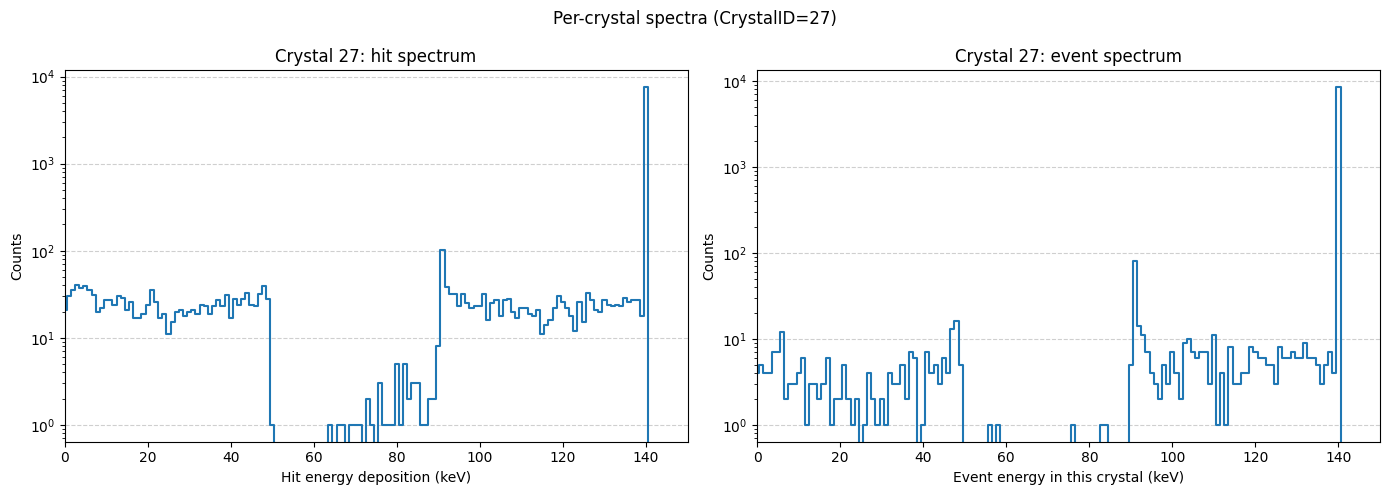

Per-crystal stats (first 10 rows):
shape: (10, 4)
┌───────────────────┬────────┬───────────────────┬──────────────────┐
│ CrystalID_fromPre ┆ n_hits ┆ mean_hit_edep_keV ┆ sum_hit_edep_keV │
│ ---               ┆ ---    ┆ ---               ┆ ---              │
│ i16               ┆ u32    ┆ f64               ┆ f64              │
╞═══════════════════╪════════╪═══════════════════╪══════════════════╡
│ 0                 ┆ 3168   ┆ 120.421251        ┆ 381494.52386     │
│ 1                 ┆ 3441   ┆ 121.845503        ┆ 419270.377071    │
│ 2                 ┆ 4127   ┆ 121.9083          ┆ 503115.553807    │
│ 3                 ┆ 5072   ┆ 122.045293        ┆ 619013.726305    │
│ 4                 ┆ 5992   ┆ 121.890193        ┆ 730366.038606    │
│ 5                 ┆ 6616   ┆ 121.572122        ┆ 804321.156096    │
│ 6                 ┆ 7232   ┆ 123.028797        ┆ 889744.259087    │
│ 7                 ┆ 8039   ┆ 121.521614        ┆ 976912.25614     │
│ 8                 ┆ 7998   ┆ 122.36808

In [18]:
# Per-crystal hit/event spectra and event-level multi-crystal energy sharing
assigned_hits = hits_pl.filter(pl.col("CrystalID_fromPre") >= 0)
print(f"Assigned hits used for spectra: {assigned_hits.height:,}")

# Event energy seen by each crystal: sum of hit energies within (FileRunID, EventID, CrystalID)
event_energy_per_crystal = (
    assigned_hits
    .group_by(["FileRunID", "EventID", "CrystalID_fromPre"])
    .agg(pl.col("EnergyDepositionKeV").sum().alias("EventCrystalEnergyKeV"))
)

# How many crystals share the same event energy deposition
event_sharing = (
    event_energy_per_crystal
    .group_by(["FileRunID", "EventID"])
    .agg(
        pl.len().alias("NumCrystalsHitInEvent"),
        pl.col("EventCrystalEnergyKeV").sum().alias("TotalEventEnergyAcrossCrystalsKeV"),
    )
    .sort("NumCrystalsHitInEvent", descending=True)
)

print("Event sharing summary (NumCrystalsHitInEvent):")
print(
    event_sharing
    .group_by("NumCrystalsHitInEvent")
    .agg(pl.len().alias("n_events"))
    .sort("NumCrystalsHitInEvent")
)

print("Top events with largest crystal sharing:")
print(event_sharing.head(20))

def plot_crystal_spectra(crystal_id: int, max_keV: float = 150.0, bin_width_keV: float = 1.0):
    hit_edep = (
        assigned_hits
        .filter(pl.col("CrystalID_fromPre") == crystal_id)
        .get_column("EnergyDepositionKeV")
        .to_numpy()
    )
    event_edep = (
        event_energy_per_crystal
        .filter(pl.col("CrystalID_fromPre") == crystal_id)
        .get_column("EventCrystalEnergyKeV")
        .to_numpy()
    )

    bins = np.arange(0, max_keV + bin_width_keV, bin_width_keV) - 0.5 * bin_width_keV

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    h1, e1 = np.histogram(hit_edep, bins=bins)
    axes[0].step(e1[:-1] + 0.5 * bin_width_keV, h1, where="mid")
    axes[0].set_yscale("log")
    axes[0].set_xlim(0, max_keV)
    axes[0].set_xlabel("Hit energy deposition (keV)")
    axes[0].set_ylabel("Counts")
    axes[0].set_title(f"Crystal {crystal_id}: hit spectrum")
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    h2, e2 = np.histogram(event_edep, bins=bins)
    axes[1].step(e2[:-1] + 0.5 * bin_width_keV, h2, where="mid")
    axes[1].set_yscale("log")
    axes[1].set_xlim(0, max_keV)
    axes[1].set_xlabel("Event energy in this crystal (keV)")
    axes[1].set_ylabel("Counts")
    axes[1].set_title(f"Crystal {crystal_id}: event spectrum")
    axes[1].grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle(f"Per-crystal spectra (CrystalID={crystal_id})")
    plt.tight_layout()
    plt.show()

# Example: crystal with the highest occupancy
top_crystal = int(
    assigned_hits
    .group_by("CrystalID_fromPre")
    .agg(pl.len().alias("n_hits"))
    .sort("n_hits", descending=True)
    .row(0)[0]
)
print(f"Plotting spectra for most-occupied crystal: {top_crystal}")
plot_crystal_spectra(top_crystal)

# Optional: map of per-crystal occupancy and mean energy
per_crystal_stats = (
    assigned_hits
    .group_by("CrystalID_fromPre")
    .agg(
        pl.len().alias("n_hits"),
        pl.col("EnergyDepositionKeV").mean().alias("mean_hit_edep_keV"),
        pl.col("EnergyDepositionKeV").sum().alias("sum_hit_edep_keV"),
    )
    .sort("CrystalID_fromPre")
)
print("Per-crystal stats (first 10 rows):")
print(per_crystal_stats.head(10))

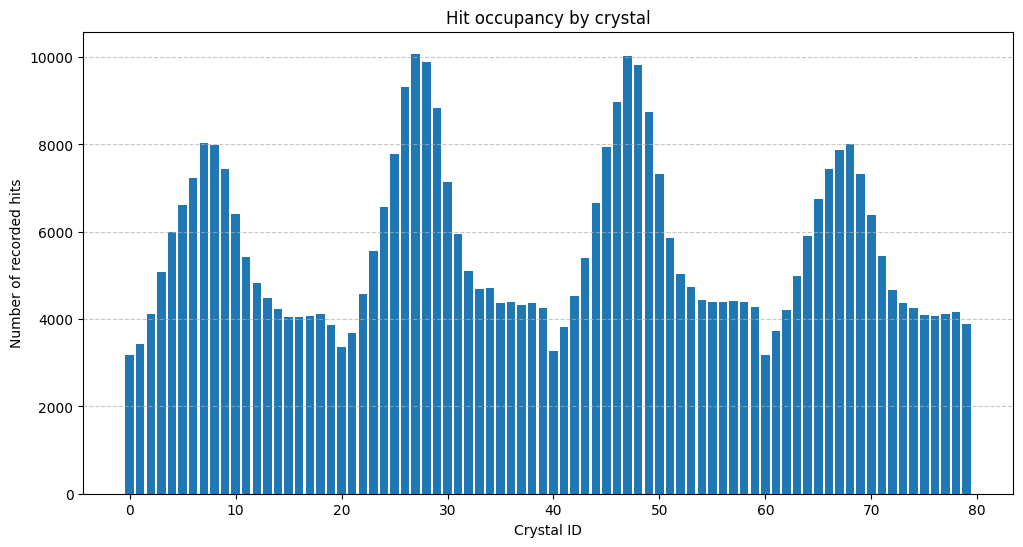

In [21]:
# Plot the number of recorded hits vs crystal ID
plt.figure(figsize=(12, 6))
plt.bar(per_crystal_stats["CrystalID_fromPre"], per_crystal_stats["n_hits"])
plt.xlabel("Crystal ID")
plt.ylabel("Number of recorded hits")
plt.title("Hit occupancy by crystal")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Saving per-crystal hit/event spectra:   0%|          | 0/80 [00:00<?, ?it/s]

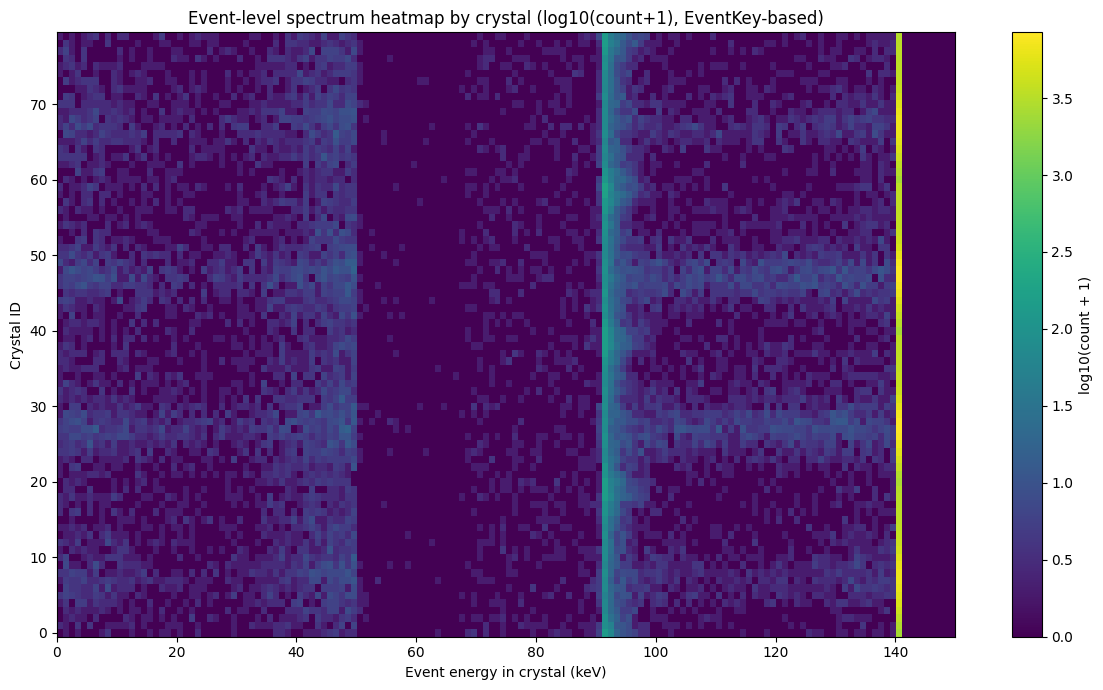

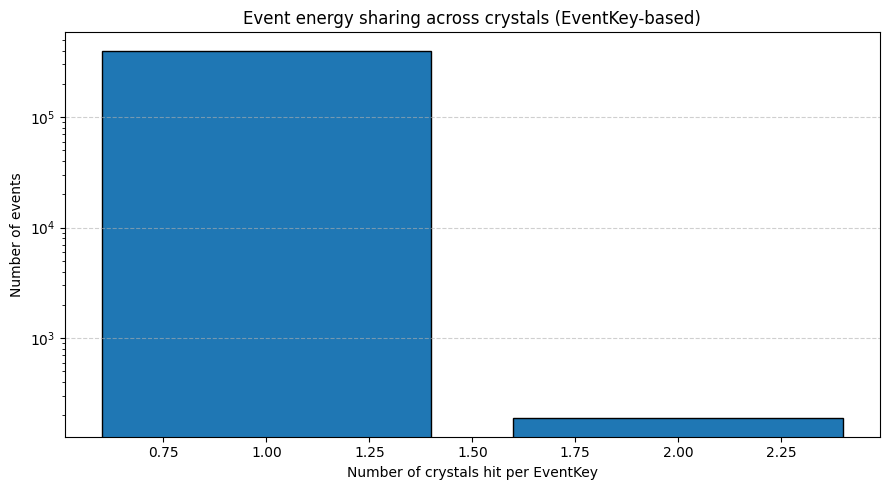

Saved all outputs to: /data/fanghan/opengate_sim/data/batch_2/analysis_outputs/all_crystal_spectra
Generated files include:
  - crystal_00_hit_event_spectra.png ... crystal_79_hit_event_spectra.png
  - event_spectrum_heatmap_by_crystal.png
  - event_sharing_histogram.png
  - event_energy_per_crystal_eventkey.csv
  - event_sharing_counts_eventkey.csv


In [20]:
# Batch-generate spectra for all crystals using EventKey-based event aggregation
from pathlib import Path

if "CrystalID_fromPre" not in hits_pl.columns:
    raise ValueError("CrystalID_fromPre not found. Run the crystal-assignment cell first.")
if "EnergyDepositionKeV" not in hits_pl.columns:
    raise ValueError("EnergyDepositionKeV not found. Run the energy-deposition cell first.")
if "EventKey" not in hits_pl.columns:
    raise ValueError("EventKey not found. Run the EventKey creation cell first.")

assigned_hits = hits_pl.filter(pl.col("CrystalID_fromPre") >= 0)

# Event-level crystal energy is aggregated by EventKey (as requested)
event_energy_per_crystal_eventkey = (
    assigned_hits
    .group_by(["EventKey", "CrystalID_fromPre"])
    .agg(pl.col("EnergyDepositionKeV").sum().alias("EventCrystalEnergyKeV"))
)

event_sharing_eventkey = (
    event_energy_per_crystal_eventkey
    .group_by("EventKey")
    .agg(
        pl.len().alias("NumCrystalsHitInEvent"),
        pl.col("EventCrystalEnergyKeV").sum().alias("TotalEventEnergyAcrossCrystalsKeV"),
    )
)

# Output location
analysis_dir = Path(sim_data_dir) / "analysis_outputs" / "all_crystal_spectra"
analysis_dir.mkdir(parents=True, exist_ok=True)

# Flatten EventKey struct for CSV export
event_energy_per_crystal_eventkey_csv = (
    event_energy_per_crystal_eventkey
    .with_columns(
        pl.col("EventKey").struct.field("FileRunID").alias("FileRunID"),
        pl.col("EventKey").struct.field("EventID").alias("EventID"),
    )
    .drop("EventKey")
    .select(["FileRunID", "EventID", "CrystalID_fromPre", "EventCrystalEnergyKeV"])
)

# Save compact tables for downstream analysis
(
    event_energy_per_crystal_eventkey_csv
    .sort(["CrystalID_fromPre", "FileRunID", "EventID"])
    .write_csv(analysis_dir / "event_energy_per_crystal_eventkey.csv")
)
(
    event_sharing_eventkey
    .group_by("NumCrystalsHitInEvent")
    .agg(pl.len().alias("n_events"))
    .sort("NumCrystalsHitInEvent")
    .write_csv(analysis_dir / "event_sharing_counts_eventkey.csv")
)

# Plotting parameters
max_keV = 150.0
bin_width_keV = 1.0
bins = np.arange(0, max_keV + bin_width_keV, bin_width_keV) - 0.5 * bin_width_keV

# Generate and save one figure per crystal: left=hit spectrum, right=event spectrum (EventKey-based)
n_crystals = 80
for crystal_id in tqdm(range(n_crystals), desc="Saving per-crystal hit/event spectra"):
    hit_edep = (
        assigned_hits
        .filter(pl.col("CrystalID_fromPre") == crystal_id)
        .get_column("EnergyDepositionKeV")
        .to_numpy()
    )
    event_edep = (
        event_energy_per_crystal_eventkey
        .filter(pl.col("CrystalID_fromPre") == crystal_id)
        .get_column("EventCrystalEnergyKeV")
        .to_numpy()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    h1, e1 = np.histogram(hit_edep, bins=bins)
    axes[0].step(e1[:-1] + 0.5 * bin_width_keV, h1, where="mid")
    axes[0].set_yscale("log")
    axes[0].set_xlim(0, max_keV)
    axes[0].set_xlabel("Hit energy deposition (keV)")
    axes[0].set_ylabel("Counts")
    axes[0].set_title(f"Crystal {crystal_id}: hit spectrum")
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    h2, e2 = np.histogram(event_edep, bins=bins)
    axes[1].step(e2[:-1] + 0.5 * bin_width_keV, h2, where="mid")
    axes[1].set_yscale("log")
    axes[1].set_xlim(0, max_keV)
    axes[1].set_xlabel("Event energy in crystal (keV)")
    axes[1].set_ylabel("Counts")
    axes[1].set_title(f"Crystal {crystal_id}: event spectrum (EventKey)")
    axes[1].grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle(f"DC-SPECT Crystal {crystal_id}")
    fig.tight_layout()
    fig.savefig(analysis_dir / f"crystal_{crystal_id:02d}_hit_event_spectra.png", dpi=150)
    plt.close(fig)

# Build a crystal x energy-bin event-spectrum heatmap
event_hist2d = np.zeros((n_crystals, len(bins) - 1), dtype=np.int64)
for crystal_id in range(n_crystals):
    event_edep = (
        event_energy_per_crystal_eventkey
        .filter(pl.col("CrystalID_fromPre") == crystal_id)
        .get_column("EventCrystalEnergyKeV")
        .to_numpy()
    )
    event_hist2d[crystal_id], _ = np.histogram(event_edep, bins=bins)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    np.log10(event_hist2d + 1),
    aspect="auto",
    origin="lower",
    extent=[bins[0] + 0.5 * bin_width_keV, bins[-1] + 0.5 * bin_width_keV, -0.5, n_crystals - 0.5],
    cmap="viridis",
)
ax.set_xlabel("Event energy in crystal (keV)")
ax.set_ylabel("Crystal ID")
ax.set_title("Event-level spectrum heatmap by crystal (log10(count+1), EventKey-based)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(count + 1)")
fig.tight_layout()
fig.savefig(analysis_dir / "event_spectrum_heatmap_by_crystal.png", dpi=180)
plt.show()

# Event-sharing plot
sharing_counts = (
    event_sharing_eventkey
    .group_by("NumCrystalsHitInEvent")
    .agg(pl.len().alias("n_events"))
    .sort("NumCrystalsHitInEvent")
)

x = sharing_counts["NumCrystalsHitInEvent"].to_numpy()
y = sharing_counts["n_events"].to_numpy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, y, width=0.8, edgecolor="black")
ax.set_yscale("log")
ax.set_xlabel("Number of crystals hit per EventKey")
ax.set_ylabel("Number of events")
ax.set_title("Event energy sharing across crystals (EventKey-based)")
ax.grid(axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()
fig.savefig(analysis_dir / "event_sharing_histogram.png", dpi=180)
plt.show()

print(f"Saved all outputs to: {analysis_dir}")
print("Generated files include:")
print("  - crystal_00_hit_event_spectra.png ... crystal_79_hit_event_spectra.png")
print("  - event_spectrum_heatmap_by_crystal.png")
print("  - event_sharing_histogram.png")
print("  - event_energy_per_crystal_eventkey.csv")
print("  - event_sharing_counts_eventkey.csv")

In [14]:
# Quantify how much deposited energy comes from secondary-like hits
secondary_hits = hits_pl.filter(
    (pl.col("ParticleType") == "lepton") &
    (pl.col("TrackCreatorProcess").is_in(["compt", "phot", "eIoni", "eBrem"]))
 ).with_columns(
    (pl.col("EnergyDepositionKeV")).alias("SecondaryEdepKeV")
)

primary_gamma_hits = hits_pl.filter(
    (pl.col("ParticleType") == "gamma") & (pl.col("TrackCreatorProcess") == "none")
 ).with_columns(
    (pl.col("EnergyDepositionKeV")).alias("PrimaryGammaEdepKeV")
)

secondary_edep_keV = secondary_hits["SecondaryEdepKeV"].sum()
primary_gamma_edep_keV = primary_gamma_hits["PrimaryGammaEdepKeV"].sum()
total_edep_keV = hits_pl["EnergyDepositionKeV"].sum()

print("Secondary-like hit energy deposition summary:")
print(f"  Secondary-like hits: {len(secondary_hits):,}")
print(f"  Primary gamma hits:   {len(primary_gamma_hits):,}")
print(f"  Secondary-like Edep:  {secondary_edep_keV:.6f} keV")
print(f"  Primary gamma Edep:    {primary_gamma_edep_keV:.6f} keV")
print(f"  Total Edep:            {total_edep_keV:.6f} keV")
print(f"  Secondary-like fraction of total: {secondary_edep_keV / total_edep_keV:.6%}")
print(f"  Primary-gamma fraction of total:   {primary_gamma_edep_keV / total_edep_keV:.6%}")

print("\nSecondary-like hits by creator process:")
print(
    secondary_hits
    .group_by("TrackCreatorProcess")
    .agg(
        pl.len().alias("n_hits"),
        pl.col("SecondaryEdepKeV").sum().alias("sum_edep_keV"),
        (pl.col("SecondaryEdepKeV").sum() / total_edep_keV).alias("frac_total"),
    )
    .sort("sum_edep_keV", descending=True)
 )

Secondary-like hit energy deposition summary:
  Secondary-like hits: 360
  Primary gamma hits:   446,522
  Secondary-like Edep:  1729.831682 keV
  Primary gamma Edep:    54361658.073282 keV
  Total Edep:            54363395.025744 keV
  Secondary-like fraction of total: 0.003182%
  Primary-gamma fraction of total:   99.996805%

Secondary-like hits by creator process:
shape: (3, 4)
┌─────────────────────┬────────┬──────────────┬────────────┐
│ TrackCreatorProcess ┆ n_hits ┆ sum_edep_keV ┆ frac_total │
│ ---                 ┆ ---    ┆ ---          ┆ ---        │
│ str                 ┆ u32    ┆ f64          ┆ f64        │
╞═════════════════════╪════════╪══════════════╪════════════╡
│ compt               ┆ 337    ┆ 1470.534495  ┆ 0.000027   │
│ phot                ┆ 21     ┆ 256.22919    ┆ 0.000005   │
│ eIoni               ┆ 2      ┆ 3.067997     ┆ 5.6435e-8  │
└─────────────────────┴────────┴──────────────┴────────────┘


In [23]:
# Reconstruct detector-crystal pose from geometry config and validate local coordinates
import pandas as pd
from scipy.spatial.transform import Rotation

persistent_data_dir = base_dir / "persistent_data"
xlsx_path = (
    persistent_data_dir
    / "spreadsheet"
    / "MDSL.excel80M10RFR.cut-plate.010.150roi.2.30pin.105ellipse.xlsx"
 )

# Match parsing logic used in create_sim_geom_dc_spect.py
df_coords = pd.read_excel(xlsx_path, sheet_name="Coordinates")
df_coords.columns = df_coords.iloc[0]
df_coords = df_coords[1:].reset_index(drop=True)
df_coords = df_coords.apply(pd.to_numeric, errors="coerce")

collimator_body_length_mm = df_coords["length of collimator"].to_numpy(dtype=float)
hole_xyz_mm = df_coords[[
    "x coordinate value at center of hole",
    "y coordinate value at center of hole",
    "z coordinate value at center of hole",
]].to_numpy(dtype=float)

detector_size_mm = np.array([50.0, 50.0, 10.0], dtype=float)
half_size_mm = detector_size_mm * 0.5

hole_r_mm = np.linalg.norm(hole_xyz_mm, axis=1)
azimuth_deg = np.degrees(np.arctan2(hole_xyz_mm[:, 1], hole_xyz_mm[:, 0]))
hole_r_xy_mm = np.linalg.norm(hole_xyz_mm[:, :2], axis=1)
polar_deg = np.degrees(np.arctan2(hole_xyz_mm[:, 2], hole_r_xy_mm))

detector_center_r_mm = hole_r_mm + collimator_body_length_mm + half_size_mm[2]
detector_center_mm = detector_center_r_mm.reshape(-1, 1) * np.column_stack(
    [
        np.cos(np.radians(polar_deg)) * np.cos(np.radians(azimuth_deg)),
        np.cos(np.radians(polar_deg)) * np.sin(np.radians(azimuth_deg)),
        np.sin(np.radians(polar_deg)),
    ]
)

# Same rotation chain as create_sim_geom_dc_spect.py
rx_0 = Rotation.from_euler("x", -90, degrees=True).as_matrix()
rz_0 = Rotation.from_euler("z", 90, degrees=True).as_matrix()
rot_mats = []
for i in range(len(detector_center_mm)):
    rz_1 = Rotation.from_euler("z", azimuth_deg[i], degrees=True).as_matrix()
    rx_1 = Rotation.from_euler("x", -polar_deg[i], degrees=True).as_matrix()
    rot_mats.append(rz_1 @ rz_0 @ rx_1 @ rx_0)
rot_mats = np.stack(rot_mats, axis=0)  # shape: (n_heads, 3, 3)

# Global unit vectors of each detector's local axes
ux = rot_mats[:, :, 0]
uy = rot_mats[:, :, 1]
uz = rot_mats[:, :, 2]

detector_axes_df = pl.DataFrame(
    {
        "HeadID": np.arange(len(detector_center_mm), dtype=int),
        "Center_X_mm": detector_center_mm[:, 0],
        "Center_Y_mm": detector_center_mm[:, 1],
        "Center_Z_mm": detector_center_mm[:, 2],
        "Ux_X": ux[:, 0], "Ux_Y": ux[:, 1], "Ux_Z": ux[:, 2],
        "Uy_X": uy[:, 0], "Uy_Y": uy[:, 1], "Uy_Z": uy[:, 2],
        "Uz_X": uz[:, 0], "Uz_Y": uz[:, 1], "Uz_Z": uz[:, 2],
    }
)
print("Detector local axes in global frame (first 5):")
print(detector_axes_df.head(5))

# Compute global AABB bounds for each oriented detector box
corner_signs = np.array(
    [
        [-1, -1, -1], [-1, -1, 1], [-1, 1, -1], [-1, 1, 1],
        [1, -1, -1], [1, -1, 1], [1, 1, -1], [1, 1, 1],
    ],
    dtype=float,
 )
local_corners = corner_signs * half_size_mm
aabb_min = np.zeros_like(detector_center_mm)
aabb_max = np.zeros_like(detector_center_mm)
for i in range(len(detector_center_mm)):
    global_corners = detector_center_mm[i] + local_corners @ rot_mats[i].T
    aabb_min[i] = global_corners.min(axis=0)
    aabb_max[i] = global_corners.max(axis=0)

detector_bounds_df = pl.DataFrame(
    {
        "HeadID": np.arange(len(detector_center_mm), dtype=int),
        "X_min_mm": aabb_min[:, 0], "X_max_mm": aabb_max[:, 0],
        "Y_min_mm": aabb_min[:, 1], "Y_max_mm": aabb_max[:, 1],
        "Z_min_mm": aabb_min[:, 2], "Z_max_mm": aabb_max[:, 2],
    }
)
print("Detector AABB bounds in global frame (first 5):")
print(detector_bounds_df.head(5))

# Validate PostPositionLocal by inverse-transforming global PostPosition
pos_cols = [
    "PostPosition_X", "PostPosition_Y", "PostPosition_Z",
    "PostPositionLocal_X", "PostPositionLocal_Y", "PostPositionLocal_Z",
]
hit_pos = hits_pl.select(pos_cols).drop_nulls().to_numpy()
global_pos = hit_pos[:, :3]
local_reported = hit_pos[:, 3:]

# Assign each hit to nearest detector center (good approximation for crystal hits)
delta = global_pos[:, None, :] - detector_center_mm[None, :, :]
head_idx = np.argmin(np.einsum("nij,nij->ni", delta, delta), axis=1)

centers_sel = detector_center_mm[head_idx]
rots_sel = rot_mats[head_idx]

# local = R^T * (global - center)
local_est = np.einsum("nij,nj->ni", np.transpose(rots_sel, (0, 2, 1)), global_pos - centers_sel)
local_err = local_est - local_reported

mae_xyz = np.mean(np.abs(local_err), axis=0)
rmse_xyz = np.sqrt(np.mean(local_err**2, axis=0))
print("Local-coordinate validation vs PostPositionLocal (nearest-head assignment):")
print(f"MAE [x,y,z] mm = {mae_xyz}")
print(f"RMSE [x,y,z] mm = {rmse_xyz}")

# Practical filter mask: events whose post-hit local position lies inside crystal box
inside_local_reported = np.all(np.abs(local_reported) <= (half_size_mm + 1e-6), axis=1)
inside_local_est = np.all(np.abs(local_est) <= (half_size_mm + 1e-6), axis=1)
agree = np.mean(inside_local_reported == inside_local_est)
print(f"Inside-box mask agreement (reported local vs transformed local): {agree:.6f}")
print(f"Fraction inside box using reported PostPositionLocal: {inside_local_reported.mean():.6f}")

Detector local axes in global frame (first 5):
shape: (5, 13)
┌────────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ HeadID ┆ Center_X_m ┆ Center_Y_m ┆ Center_Z_m ┆ … ┆ Uy_Z      ┆ Uz_X      ┆ Uz_Y      ┆ Uz_Z     │
│ ---    ┆ m          ┆ m          ┆ m          ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i64    ┆ ---        ┆ ---        ┆ ---        ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│        ┆ f64        ┆ f64        ┆ f64        ┆   ┆           ┆           ┆           ┆          │
╞════════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0      ┆ 365.555941 ┆ 92.868011  ┆ -92.425995 ┆ … ┆ -0.971263 ┆ -0.94136  ┆ -0.239149 ┆ 0.23801  │
│ 1      ┆ 320.439665 ┆ 141.510936 ┆ -92.695436 ┆ … ┆ -0.966726 ┆ -0.884331 ┆ -0.390534 ┆ 0.255816 │
│ 2      ┆ 265.494104 ┆ 180.488297 ┆ -93.035671 ┆ … ┆ -0.960481 ┆ -0.794313 ┆ -0.53999  ┆ 0.278347 │
│ 3      ┆ 204.269957 ┆ 208.7

In [25]:
# Range of local coordinates in simulated hit data
local_cols = ["PostPositionLocal_X", "PostPositionLocal_Y", "PostPositionLocal_Z"]
for c in local_cols:
    s = hits_pl[c]
    print(
        f"{c}: min={s.min():.6f}, max={s.max():.6f}, "
        f"q0.1%={s.quantile(0.001):.6f}, q99.9%={s.quantile(0.999):.6f}"
    )

PostPositionLocal_X: min=-306.068654, max=366.265517, q0.1%=-24.979301, q99.9%=24.981561
PostPositionLocal_Y: min=-316.766672, max=248.305563, q0.1%=-24.981965, q99.9%=24.981479
PostPositionLocal_Z: min=-116.496768, max=99.215594, q0.1%=-4.989013, q99.9%=4.998222


In [26]:
# Range comparison: PrePositionLocal vs PostPositionLocal
for prefix in ["PrePositionLocal", "PostPositionLocal"]:
    print(f"\n{prefix} ranges:")
    for axis in ["X", "Y", "Z"]:
        c = f"{prefix}_{axis}"
        s = hits_pl[c]
        print(
            f"{c}: min={s.min():.6f}, max={s.max():.6f}, "
            f"q0.1%={s.quantile(0.001):.6f}, q99.9%={s.quantile(0.999):.6f}"
        )


PrePositionLocal ranges:
PrePositionLocal_X: min=-25.000000, max=25.000000, q0.1%=-25.000000, q99.9%=25.000000
PrePositionLocal_Y: min=-25.000000, max=25.000000, q0.1%=-25.000000, q99.9%=25.000000
PrePositionLocal_Z: min=-5.000000, max=5.000000, q0.1%=-5.000000, q99.9%=5.000000

PostPositionLocal ranges:
PostPositionLocal_X: min=-306.068654, max=366.265517, q0.1%=-24.979301, q99.9%=24.981561
PostPositionLocal_Y: min=-316.766672, max=248.305563, q0.1%=-24.981965, q99.9%=24.981479
PostPositionLocal_Z: min=-116.496768, max=99.215594, q0.1%=-4.989013, q99.9%=4.998222


## Calculate Sensitivity (Detector Efficiency)

In [5]:
# Calculate Sensitivity using only RunID = 0
run_0_hits = hits_pl.filter(pl.col("RunID") == 0)
unique_event_ids, event_counts = np.unique(
    run_0_hits["EventID"].to_numpy(), return_counts=True
)
total_events = 64_000_000
detected_events = len(unique_event_ids)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events}")
print(f"Detected events: {detected_events}")
print(f"Detection efficiency: {detection_efficiency:.3%}")

Total simulated events: 64000000
Detected events: 397071
Detection efficiency: 0.620%


In [6]:
# Print total number of unique events and detection efficiency
per_run_events = 64_000_000
n_runs = len(root_files)
total_events = per_run_events * n_runs
# Get unique EventIDs with unique RunID combinations
unique_event_run_combinations = hits_df[["RunID", "EventID"]].drop_duplicates()
detected_events = len(unique_event_run_combinations)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events:,}")
print(f"Detected events: {detected_events:,}")
print(f"Detection efficiency: {detection_efficiency:.3%}")


Total simulated events: 640,000,000
Detected events: 397,071
Detection efficiency: 0.062%


In [7]:
# Histogram the counts of unique EventIDs
hist, bin_edges = np.histogram(event_counts, bins=np.arange(0.5, event_counts.max() + 1.5, 1))

fig = px.bar(
    x=bin_edges[:-1]+0.5,  # Center the bins
    y=hist,
    labels={'x': 'Number of hits per Event', 'y': 'Number of Events'},
    title="Distribution of hits per Event"

)

# 2. Replicate the 'edgecolor' and 'width' look
fig.update_traces(
    marker_line_color='black', 
    marker_line_width=1.5,
    opacity=0.8
)

fig.update_layout(bargap=0)

fig.show()

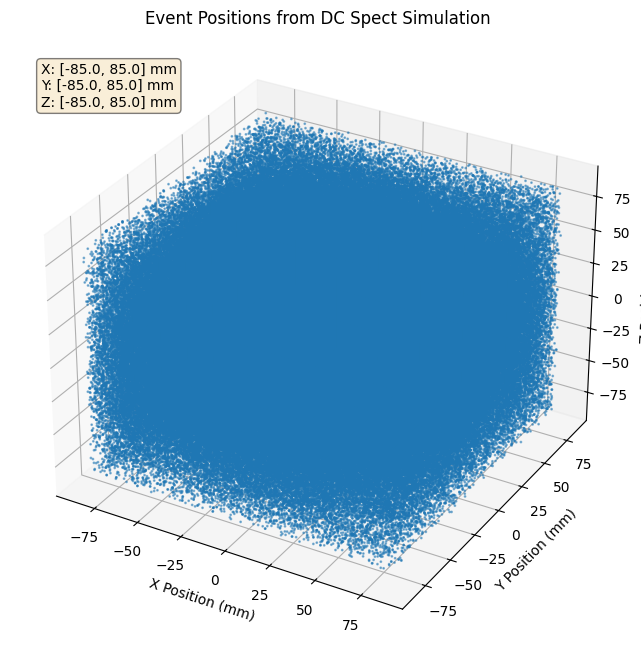

In [8]:
# Plot event positions in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(event_pos_xyz[:, 0], event_pos_xyz[:, 1], event_pos_xyz[:, 2], s=1, alpha=0.5)
ax.set_xlabel('X Position (mm)')
ax.set_ylabel('Y Position (mm)')
ax.set_zlabel('Z Position (mm)')
# Add a text box showing the max and min of each coordinate
textstr = '\n'.join((
    f'X: [{event_pos_xyz[:, 0].min():.1f}, {event_pos_xyz[:, 0].max():.1f}] mm',
    f'Y: [{event_pos_xyz[:, 1].min():.1f}, {event_pos_xyz[:, 1].max():.1f}] mm',
    f'Z: [{event_pos_xyz[:, 2].min():.1f}, {event_pos_xyz[:, 2].max():.1f}] mm',
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text2D(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
ax.set_title('Event Positions from DC Spect Simulation')
plt.show()

In [9]:
# Print total number of unique events and detection efficiency
per_run_events = 64_000_000
n_runs = len(root_files)
total_events = per_run_events * n_runs
# Get unique EventIDs with unique RunID combinations
unique_event_run_combinations = hits_df[["RunID", "EventID"]].drop_duplicates()
detected_events = len(unique_event_run_combinations)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events:,}")
print(f"Detected events: {detected_events:,}")
print(f"Detection efficiency: {detection_efficiency:.3%}")

Total simulated events: 640,000,000
Detected events: 397,071
Detection efficiency: 0.062%


## Analyze the events with only 1 ht in the detectors, using Polars


In [5]:
# Check if RunID 0 has the same number of unique EventIDs as the total across all runs
run_0_unique_event_ids = hits_pl.filter(pl.col("RunID") == 0)["EventID"].unique()
total_unique_event_ids = hits_pl.select(pl.col("EventID").unique())
print(f"Unique EventIDs in RunID 0: {len(run_0_unique_event_ids):,}")
print(f"Total unique EventIDs across all runs: {len(total_unique_event_ids):,}")



Unique EventIDs in RunID 0: 397,071
Total unique EventIDs across all runs: 397,071


In [6]:
# Print unique RunIDs and their count
unique_run_ids = hits_pl["RunID"].unique()
print(f"Unique RunIDs: {unique_run_ids}")
print(f"Number of unique RunIDs: {len(unique_run_ids)}")

Unique RunIDs: shape: (1,)
Series: 'RunID' [i32]
[
	0
]
Number of unique RunIDs: 1


In [76]:
# Numerical precision check around 140 keV threshold
max_total_edep = energy_deposition_per_event["TotalEnergyDeposition"].max()
count_gt_140 = energy_deposition_per_event.filter(pl.col("TotalEnergyDeposition") > 140).height
count_gt_140_eps = energy_deposition_per_event.filter(pl.col("TotalEnergyDeposition") > 140 + 1e-6).height
count_gt_141 = energy_deposition_per_event.filter(pl.col("TotalEnergyDeposition") > 141).height

print(f"Max total deposition: {max_total_edep:.12f} keV")
print(f"Count > 140 keV: {count_gt_140:,}")
print(f"Count > 140 + 1e-6 keV: {count_gt_140_eps:,}")
print(f"Count > 141 keV: {count_gt_141:,}")

Max total deposition: 140.000000000000 keV
Count > 140 keV: 12,919
Count > 140 + 1e-6 keV: 0
Count > 141 keV: 0


In [81]:
# TrackID integrity diagnostics
print(f"TrackID column present: {'TrackID' in hits_pl.columns}")
print(f"Unique TrackID values (global): {hits_pl['TrackID'].n_unique():,}")
print(f"Unique TrackKey values (FileRunID+EventID+TrackID): {hits_pl['TrackKey'].n_unique():,}")

trackid_event_multiplicity = hits_pl.group_by("TrackID").agg(
    pl.col("EventKey").n_unique().alias("NumEventsSharingTrackID")
)
shared_trackids = trackid_event_multiplicity.filter(pl.col("NumEventsSharingTrackID") > 1)
print(f"TrackID values reused across events: {len(shared_trackids):,}")
if len(shared_trackids) > 0:
    print(shared_trackids.sort("NumEventsSharingTrackID", descending=True).head(10))

TrackID column present: True
Unique TrackID values (global): 5
Unique TrackKey values (FileRunID+EventID+TrackID): 398,218
TrackID values reused across events: 4
shape: (4, 2)
┌─────────┬─────────────────────────┐
│ TrackID ┆ NumEventsSharingTrackID │
│ ---     ┆ ---                     │
│ i32     ┆ u32                     │
╞═════════╪═════════════════════════╡
│ 1       ┆ 398122                  │
│ 2       ┆ 88                      │
│ 3       ┆ 5                       │
│ 4       ┆ 2                       │
└─────────┴─────────────────────────┘
